<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec03_scikt_learn_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# scikit-learn 기초 실습

이 실습에서는 scikit-learn 라이브러리의 기본 사용법을 학습합니다:
1. 내장 데이터셋 로딩 및 탐색
2. Bunch 객체 이해
3. 다양한 분류 모델 사용 (SVC, Decision Tree, KNN)

**scikit-learn 기본 패턴:**
```python
model = Model()           # 모델 생성
model.fit(X_train, y_train)  # 학습
y_pred = model.predict(X_test)  # 예측
```

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

---
## Part 1: 데이터셋 로딩 (15점)

scikit-learn은 다양한 내장 데이터셋을 제공합니다.
- `load_digits()`: 손글씨 숫자 (8x8 이미지)
- `load_iris()`: 붓꽃 분류
- `load_wine()`: 와인 분류

---

### 문제 1-1. Digits 데이터셋 로딩 [10점]

**문제:** `datasets.load_digits()`를 사용하여 손글씨 숫자 데이터셋을 로딩하세요.

**힌트:**
```python
digits = datasets.load_digits()
```

**예상 결과:** 1797개의 샘플, 64개의 특성

In [2]:
#@title { vertical-output: true}
# IMPLEMENT HERE: digits 데이터셋 로딩
digits = datasets.load_digits()

# 데이터셋 정보 확인
print("Dataset keys:", digits.keys())
print(f"\nData shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Target names: {digits.target_names}")
print(f"\nNumber of samples: {len(digits.data)}")
print(f"Number of features: {digits.data.shape[1]}")

Dataset keys: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

Data shape: (1797, 64)
Target shape: (1797,)
Target names: [0 1 2 3 4 5 6 7 8 9]

Number of samples: 1797
Number of features: 64


### 문제 1-2. Bunch 객체 이해 [5점]

scikit-learn의 데이터셋은 `Bunch` 객체로 반환됩니다.
딕셔너리처럼 키로 접근하거나, 속성으로 접근할 수 있습니다.

**예상 결과:** 두 가지 접근 방식이 동일한 결과

In [3]:
#@title { vertical-output: true}
from sklearn.utils import Bunch

# Bunch 객체 생성 예제
my_bunch = Bunch(name='example', value=42)
print("Bunch object:", my_bunch)

# 두 가지 접근 방식
print(f"\nAccess by key: my_bunch['name'] = {my_bunch['name']}")
print(f"Access by attribute: my_bunch.name = {my_bunch.name}")

# digits 데이터셋도 동일
print(f"\ndigits['target'][0] = {digits['target'][0]}")
print(f"digits.target[0] = {digits.target[0]}")

Bunch object: {'name': 'example', 'value': 42}

Access by key: my_bunch['name'] = example
Access by attribute: my_bunch.name = example

digits['target'][0] = 0
digits.target[0] = 0


---
## Part 2: 데이터 시각화 (10점)

손글씨 숫자 이미지를 시각화합니다. 각 이미지는 8x8 크기입니다.

---

### 문제 2-1. 단일 이미지 시각화 [10점]

**문제:** 지정된 인덱스의 이미지를 8x8로 reshape하여 시각화하세요.

**힌트:**
```python
image = digits.data[idx].reshape(8, 8)
plt.imshow(image, cmap='gray')
```

**예상 결과:** 해당 숫자의 흑백 이미지

Index: 14
Label: 4
Image shape: (8, 8)


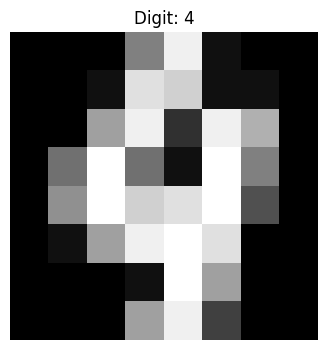

In [4]:
#@title { vertical-output: true}
idx = 14

# IMPLEMENT HERE: 이미지 reshape
image = digits.data[idx].reshape(8, 8)

print(f"Index: {idx}")
print(f"Label: {digits.target[idx]}")
print(f"Image shape: {image.shape}")

# IMPLEMENT HERE: 이미지 시각화
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title(f'Digit: {digits.target[idx]}')
plt.axis('off')
plt.show()

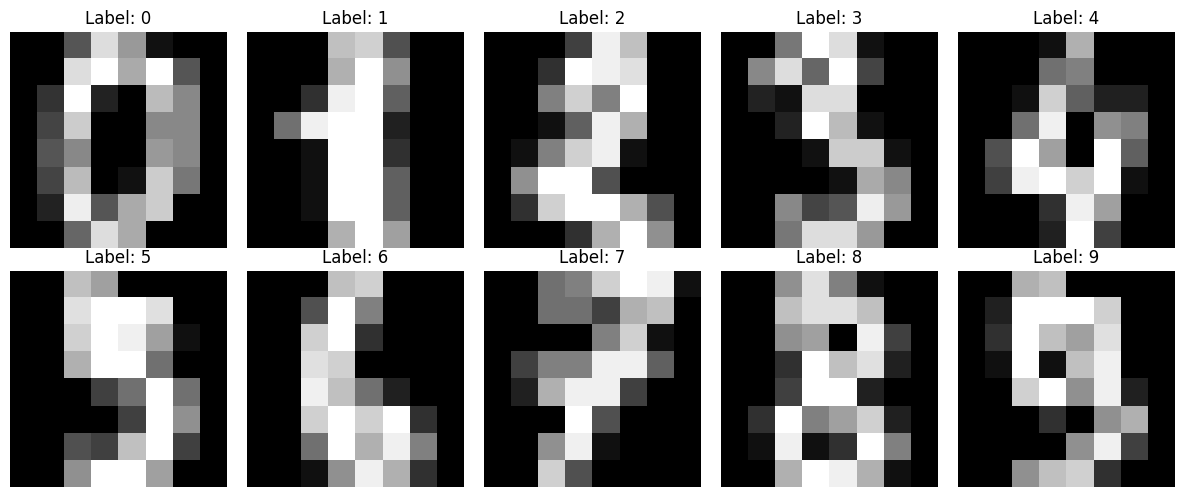

In [5]:
#@title { vertical-output: true}
# 여러 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(digits.data[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Part 3: 데이터 분할 (10점)

학습용(train)과 테스트용(test) 데이터로 분할합니다.

---

### 문제 3-1. Train/Test 분할 [10점]

**문제:** `train_test_split`을 사용하여 데이터를 분할하세요.

**힌트:**
```python
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)
```

**예상 결과:** Train 1437개, Test 360개

In [6]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

print(f"Train data: {X_train.shape[0]} samples")
print(f"Test data: {X_test.shape[0]} samples")
print(f"\nTrain ratio: {len(X_train) / len(digits.data):.1%}")
print(f"Test ratio: {len(X_test) / len(digits.data):.1%}")

Train data: 1437 samples
Test data: 360 samples

Train ratio: 80.0%
Test ratio: 20.0%


---
## Part 4: SVM (Support Vector Machine) 분류 (20점)

SVM은 고차원 데이터에서 효과적인 분류 알고리즘입니다.

**주요 파라미터:**
- `gamma`: RBF 커널의 영향 범위
- `C`: 오분류에 대한 패널티

---

### 문제 4-1. SVC 모델 학습 및 예측 [20점]

**문제:** SVC 모델을 생성하고, 학습(fit)한 후, 예측(predict)하세요.

**힌트:**
```python
from sklearn import svm
model = svm.SVC(gamma=0.001, C=100.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

**예상 결과:** 정확도 약 98% 이상

In [8]:
#@title { vertical-output: true}
from sklearn import svm

# IMPLEMENT HERE: SVC 모델 생성
model = svm.SVC(gamma=0.001, C=100.0)

# IMPLEMENT HERE: 모델 학습
model.fit(X_train, y_train)

# IMPLEMENT HERE: 예측
y_pred_svc = model.predict(X_test)

# 정확도 계산
acc_svc = accuracy_score(y_test, y_pred_svc)
print("=" * 40)
print("SVM (Support Vector Machine)")
print("=" * 40)
print(f"Accuracy: {acc_svc:.4f}")

SVM (Support Vector Machine)
Accuracy: 0.9889


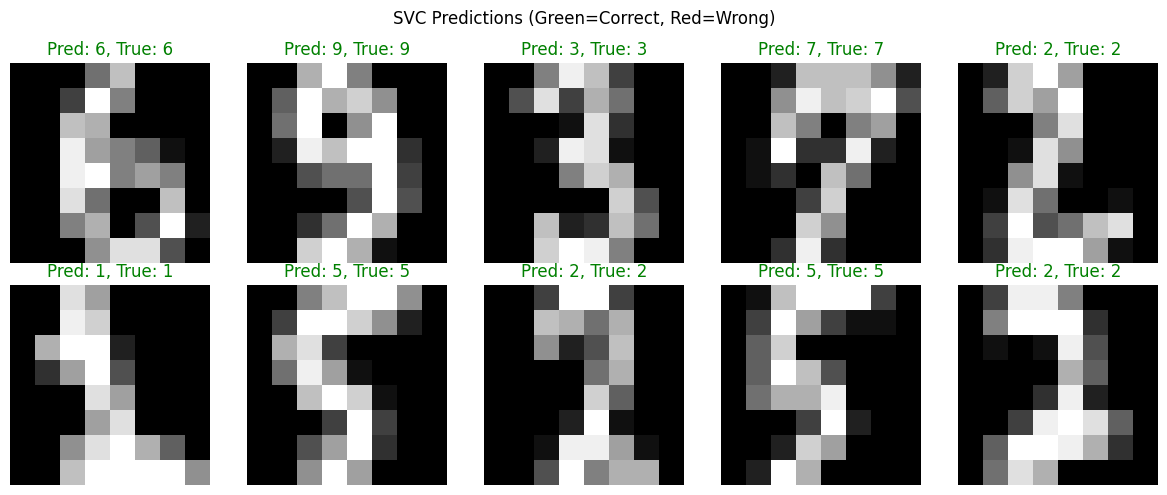

In [9]:
#@title { vertical-output: true}
# 예측 결과 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    color = 'green' if y_pred_svc[i] == y_test[i] else 'red'
    ax.set_title(f'Pred: {y_pred_svc[i]}, True: {y_test[i]}', color=color)
    ax.axis('off')

plt.suptitle('SVC Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 5: Decision Tree 분류 (20점)

Decision Tree는 해석이 쉽고 시각화가 가능한 분류 알고리즘입니다.

**주요 파라미터:**
- `max_depth`: 트리의 최대 깊이
- `min_samples_split`: 분할에 필요한 최소 샘플 수

---

### 문제 5-1. Decision Tree 모델 학습 및 예측 [20점]

**문제:** DecisionTreeClassifier 모델을 생성하고, 학습한 후, 예측하세요.

**힌트:**
```python
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

**예상 결과:** 정확도 약 85% 이상

In [10]:
#@title { vertical-output: true}
from sklearn.tree import DecisionTreeClassifier

# IMPLEMENT HERE: Decision Tree 모델 생성
dt_model = DecisionTreeClassifier(random_state=42)

# IMPLEMENT HERE: 모델 학습
dt_model.fit(X_train, y_train)

# IMPLEMENT HERE: 예측
y_pred_dt = dt_model.predict(X_test)

# 정확도 계산
acc_dt = accuracy_score(y_test, y_pred_dt)
print("=" * 40)
print("Decision Tree")
print("=" * 40)
print(f"Accuracy: {acc_dt:.4f}")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

Decision Tree
Accuracy: 0.8417
Tree depth: 15
Number of leaves: 145


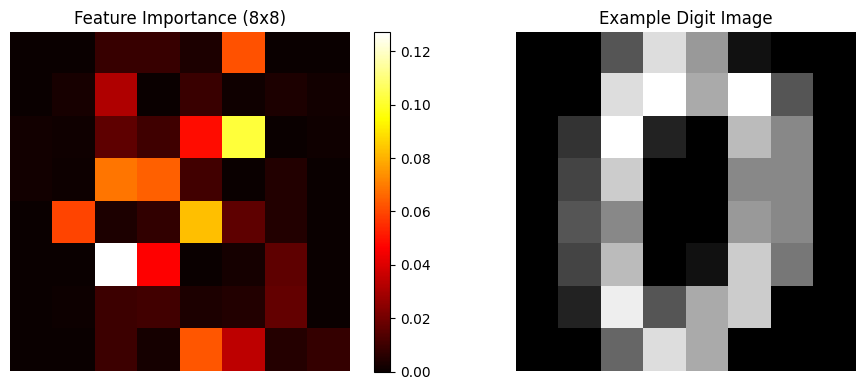

In [11]:
#@title { vertical-output: true}
# Feature Importance 시각화
importance = dt_model.feature_importances_.reshape(8, 8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Feature importance heatmap
im = axes[0].imshow(importance, cmap='hot')
axes[0].set_title('Feature Importance (8x8)')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

# 예시 이미지와 비교
axes[1].imshow(digits.data[0].reshape(8, 8), cmap='gray')
axes[1].set_title('Example Digit Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Part 6: K-Nearest Neighbors (KNN) 분류 (20점)

KNN은 가장 가까운 K개의 이웃을 기반으로 분류하는 알고리즘입니다.

**주요 파라미터:**
- `n_neighbors`: 고려할 이웃의 수 (K)
- `weights`: 가중치 방식 ('uniform' 또는 'distance')

---

### 문제 6-1. KNN 모델 학습 및 예측 [20점]

**문제:** KNeighborsClassifier 모델을 생성하고, 학습한 후, 예측하세요.

**힌트:**
```python
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

**예상 결과:** 정확도 약 97% 이상

In [12]:
#@title { vertical-output: true}
from sklearn.neighbors import KNeighborsClassifier

# IMPLEMENT HERE: KNN 모델 생성 (n_neighbors=3)
knn_model = KNeighborsClassifier(n_neighbors=3)

# IMPLEMENT HERE: 모델 학습
knn_model.fit(X_train, y_train)

# IMPLEMENT HERE: 예측
y_pred_knn = knn_model.predict(X_test)

# 정확도 계산
acc_knn = accuracy_score(y_test, y_pred_knn)
print("=" * 40)
print("K-Nearest Neighbors (KNN)")
print("=" * 40)
print(f"Accuracy: {acc_knn:.4f}")
print(f"Number of neighbors (K): {knn_model.n_neighbors}")

K-Nearest Neighbors (KNN)
Accuracy: 0.9833
Number of neighbors (K): 3


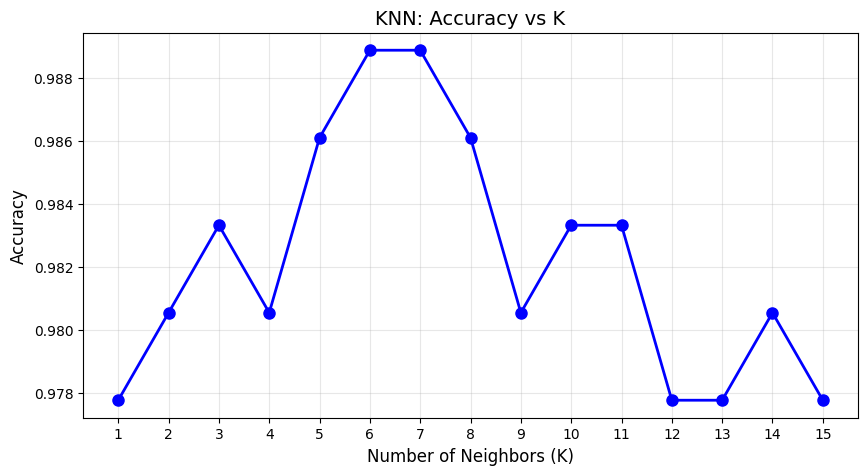

Best K: 6 (Accuracy: 0.9889)


In [13]:
#@title { vertical-output: true}
# K 값에 따른 정확도 변화
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs K', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best K: {best_k} (Accuracy: {max(accuracies):.4f})")

---
## Part 7: 모델 비교 (5점)

세 가지 모델의 성능을 비교합니다.

---

Model Comparison on Digits Dataset
Model                     |   Accuracy
--------------------------------------------------
SVM (SVC)                 |     0.9889
Decision Tree             |     0.8417
KNN (K=3)                 |     0.9833


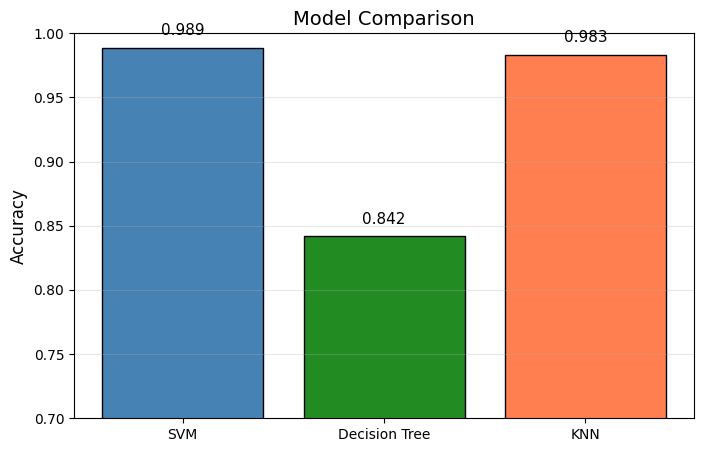

In [14]:
#@title { vertical-output: true}
print("=" * 50)
print("Model Comparison on Digits Dataset")
print("=" * 50)
print(f"{'Model':<25} | {'Accuracy':>10}")
print("-" * 50)
print(f"{'SVM (SVC)':<25} | {acc_svc:>10.4f}")
print(f"{'Decision Tree':<25} | {acc_dt:>10.4f}")
print(f"{'KNN (K=3)':<25} | {acc_knn:>10.4f}")
print("=" * 50)

# 막대 그래프
models = ['SVM', 'Decision Tree', 'KNN']
accuracies_all = [acc_svc, acc_dt, acc_knn]
colors = ['steelblue', 'forestgreen', 'coral']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies_all, color=colors, edgecolor='black')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison', fontsize=14)
plt.ylim(0.7, 1.0)

for bar, acc in zip(bars, accuracies_all):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `scikt_learn_학번_이름.ipynb`, `scikt_learn_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---